Import Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score

from imblearn.over_sampling import SMOTE

Load Dataset

In [2]:
data = pd.read_csv("D:\credit card fraud detection\CreditCardFraudDetection\dataset\creditcard.csv")


Display Dataset Information

In [3]:
print(data.head())
print(data.info())
print(data.shape)

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

Data Preprocessing


a. Check missing values

In [4]:
data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

b. Normalize Amount column

In [5]:
scaler = StandardScaler()
data['Amount'] = scaler.fit_transform(data[['Amount']])

c. Separate Features and Target

In [6]:
X = data.drop('Class', axis=1)
y = data['Class']

Handle Class Imbalance using SMOTE

In [7]:
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X, y)

Split Dataset

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)
# Print Shapes
print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (454904, 30)
X_test Shape : (113726, 30)
y_train Shape: (454904,)
y_test Shape : (113726,)


Train Machine Learning Model

Model — Random Forest

In [9]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

Evaluate Model

a. Confusion Matrix

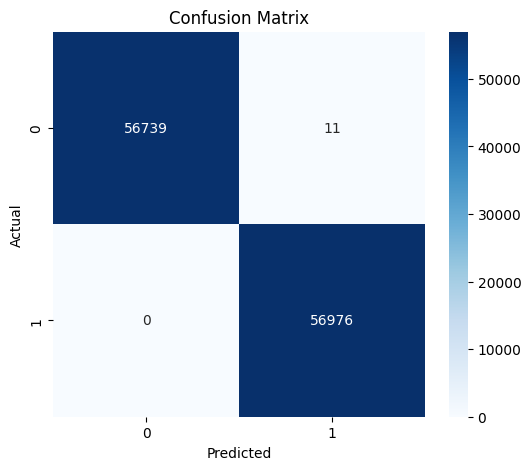

In [34]:
confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

b. Classification Report

In [12]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



c. Accuracy Score

In [13]:
accuracy = accuracy_score(y_test, y_pred_rf)

print("Accuracy:", accuracy)

Accuracy: 0.999903276295658


c. ROC-AUC Score

In [14]:
roc_auc_score(y_test, y_pred_rf)

0.9999030837004405

Data Visualization

a. ROC Curve

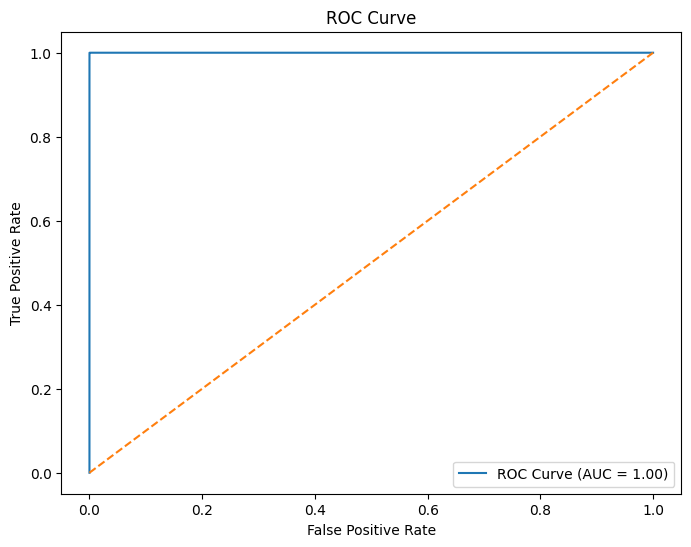

In [15]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability predictions
y_prob = rf.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr,
         label='ROC Curve (AUC = %0.2f)' % roc_auc)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend(loc='lower right')

plt.show()

b. Feature Importance Values

In [16]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head(10))

   Feature  Importance
14     V14    0.203177
12     V12    0.133589
4       V4    0.126802
10     V10    0.103098
17     V17    0.090724
11     V11    0.083189
16     V16    0.037792
3       V3    0.036433
7       V7    0.027176
9       V9    0.023803


Plot Graph


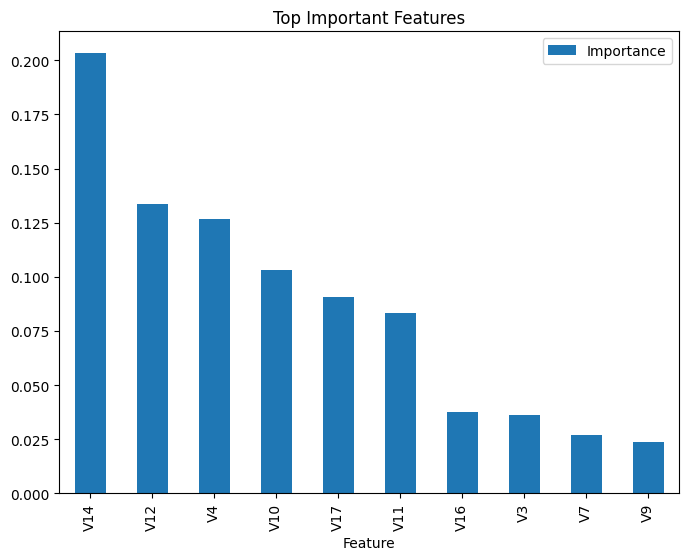

In [17]:
importance_df.head(10).plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(8,6)
)

plt.title("Top Important Features")

plt.show()

c. Fraud vs Genuine Count

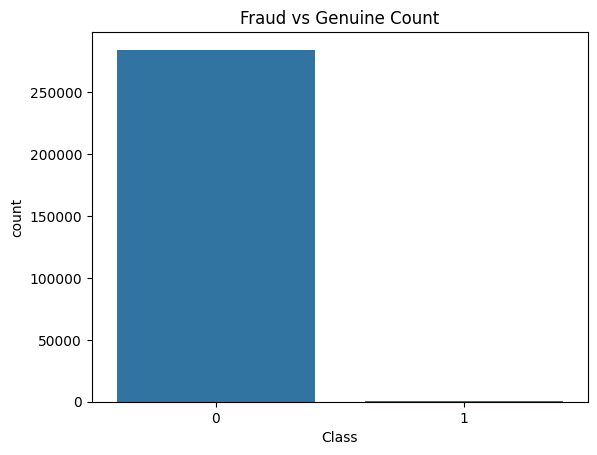

In [29]:
sns.countplot(x='Class', data=data)

plt.title("Fraud vs Genuine Count")
plt.show()

d. Correlation Heatmap

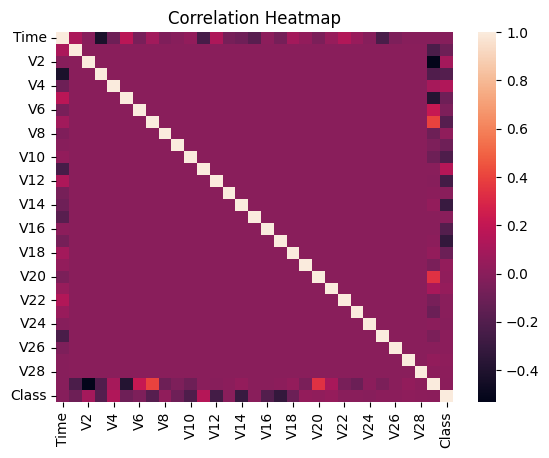

In [30]:
sns.heatmap(data.corr())

plt.title("Correlation Heatmap")
plt.show()

Reduce False Positives

In [20]:
y_prob = rf.predict_proba(X_test)[:,1]

threshold = 0.7

y_custom = (y_prob > threshold).astype(int)

Prediction Function

In [21]:
def predict_transaction(data):

    prediction = rf.predict(data)

    if prediction[0] == 1:
        return "Fraudulent Transaction"

    else:
        return "Genuine Transaction"

Complete Prediction Example

In [25]:

sample = X_test.iloc[10:11]

prediction = rf.predict(sample)

if prediction[0] == 1:
    print("Fraudulent Transaction")
else:
    print("Genuine Transaction")

print("Actual Class:", y_test.iloc[10])

Genuine Transaction
Actual Class: 0


Predict Custom Transaction

In [26]:
import numpy as np

new_transaction = np.array([[0.5, -1.2, 0.8, 1.5, 0.3,
                             -0.7, 1.1, 0.2, -1.4, 0.6,
                             0.5, -0.3, 0.7, 1.2, -0.9,
                             0.4, 1.1, -0.5, 0.2, 0.8,
                             -1.0, 0.3, 0.4, -0.2, 0.9,
                             1.5, -0.6, 0.7, 150]])
probability = rf.predict_proba(sample)

print(probability)

[[0.99 0.01]]


Save Model

In [27]:
import joblib

joblib.dump(rf, 'fraud_model.pkl')

['fraud_model.pkl']